In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('titanic.csv')
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [4]:
df['number'].unique()

<ArrowStringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

findfont: Failed to find font weight normal, now using 700.


Text(0.5, 1.0, 'Passengers travelling ')

findfont: Failed to find font weight normal, now using 700.


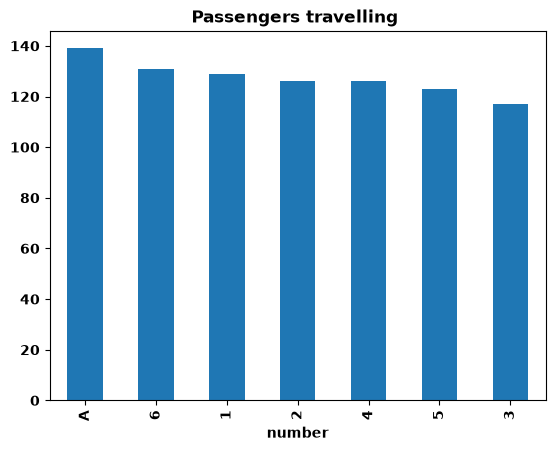

In [5]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling ')

In [6]:
# extract numerical part

df['number_numrical'] = pd.to_numeric(df['number'], errors='coerce', downcast='integer')

In [7]:
df['number_categorical'] = np.where(df['number_numrical'].isnull(), df['number'], np.nan)

df.head()

,Cabin,Ticket,number,Survived,number_numrical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [8]:
df['Cabin'].unique()

<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [9]:
df['Ticket'].unique()

<ArrowStringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

In [10]:
# Extract cabin number
df['cabin_num'] = df['Cabin'].str.extract(r'(\d+)')

# Extract cabin category (first letter)
df['cabin_cat'] = df['Cabin'].str[0]

df.head()

,Cabin,Ticket,number,Survived,number_numrical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


In [11]:
df['cabin_cat'].value_counts()

cabin_cat
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [13]:
# Extract the last part of the ticket
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])

# Convert to numeric
df['ticket_num'] = pd.to_numeric(
    df['ticket_num'],
    errors='coerce',
    downcast='integer'
)

# Extract the ticket category
df['ticket_cat'] = df['Ticket'].apply(
    lambda s: s.split()[0] if not s.split()[-1].isdigit() else 'NONE'
)

In [14]:
df.head()

,Cabin,Ticket,number,Survived,number_numrical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,NONE
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,NONE
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,NONE
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NONE
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NONE


In [15]:
df.drop(columns=['Cabin', 'Ticket', 'number'])

,Survived,number_numrical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,0,5.0,NaN,NaN,NaN,21171.0,NONE
1,1,3.0,NaN,85,C,17599.0,NONE
2,1,6.0,NaN,NaN,NaN,3101282.0,NONE
3,1,3.0,NaN,123,C,113803.0,NONE
4,0,NaN,A,NaN,NaN,373450.0,NONE
...,...,...,...,...,...,...,...
886,0,3.0,NaN,NaN,NaN,211536.0,NONE
887,1,3.0,NaN,42,B,112053.0,NONE
888,0,1.0,NaN,NaN,NaN,6607.0,NONE
889,1,2.0,NaN,148,C,111369.0,NONE
